# Artificial Nural Network


* **Structure of Artificial Neural Network**
    * An ANN has 3 main types of layers:
        1. Input Layer:
            * Takes the input features (e.g., pixels of an image, values in a dataset).
            * No computation — just passes data forward.
        2. Hidden Layers:
            * Perform all the computation (matrix multiplication, activation).
            * Each neuron applies a weighted sum + activation function.
        3. Output Layer:
            * Produces the final result (e.g., class label, probability, predicted value).
    * Input Layer → Hidden Layer 1 → Hidden Layer 2 → Output Layer
    * In a nural network only **one input** layer and only **one output** layer and **one or more then one hidden layers** will be.

* **Working of a Neuron**
    * Each **neuron** performs 2 operations :
        1. $z = w_1x_1 + w_2x_2 + ... + w_nx_n + b$  ``(Summition Operation)``
        2. $Output = Activation(z)$ ``(Activation Function)``
        * Where:
            * $x_i$ : Inputs
            * $w_i$ : Weights
            * $b$ : Bias
            * $Activation(z)$ : Non-linear transformation
    * **Weight :**
        * First time nural network take weights random. and this is decided by the the nural network itself.
        * Your nural network is learning by changing the weight values and getting the most effective output and after a while intelligence the your model is saved in weights
    * **Bias :**
        * Bias will only be added to the hidden layers.
        * to tune the nural network in right direction we add bias.
        * Bias values are also completely random and decided by nural network.
    * 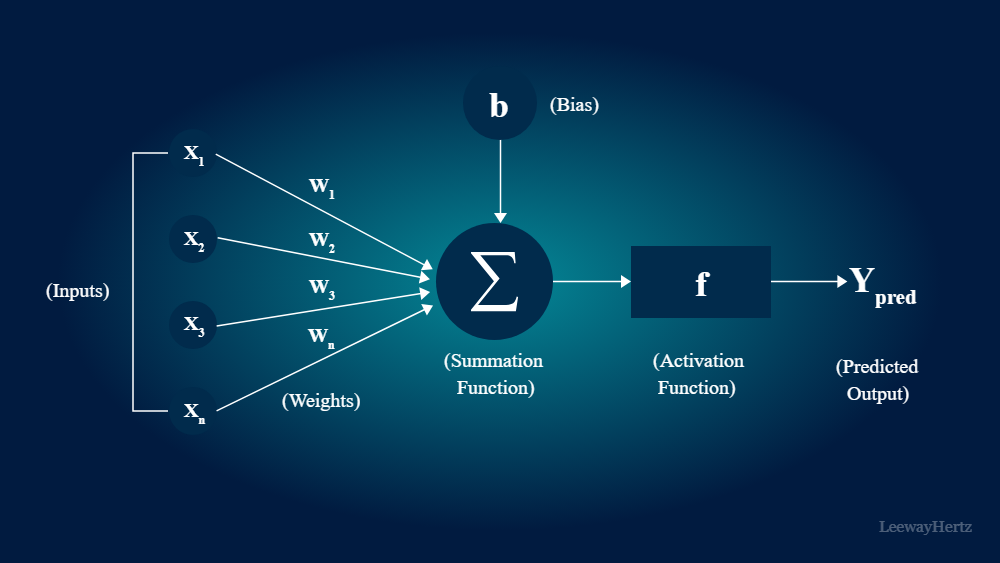

* **Activation Functions**
    * Hamare pass hamesa linear data nhi rahta and agar linear data nhi to DL model to pattern(relations) samajhne me problem hoti hai so
    * Activation function Introduces non-linearity into the model – allows the model to learn complex relationships in data.
    * 



* **Forword Propogation**
    * Forward Propagation is the process of moving input data through the neural network — from the input layer → hidden layers → output layer — to get a predicted output.
    1. Summision operation of inputs and weights qnd bias
        * z = $w_1.x_1 + w_2.x_2 + w_3.x_3 + w_n.x_n + b$

    2. Now pass it to Activation Function 
        * $ f(x) = \frac{1}{1 + e^{-x}} $
        * where need to put output of summision **z** in **x**

        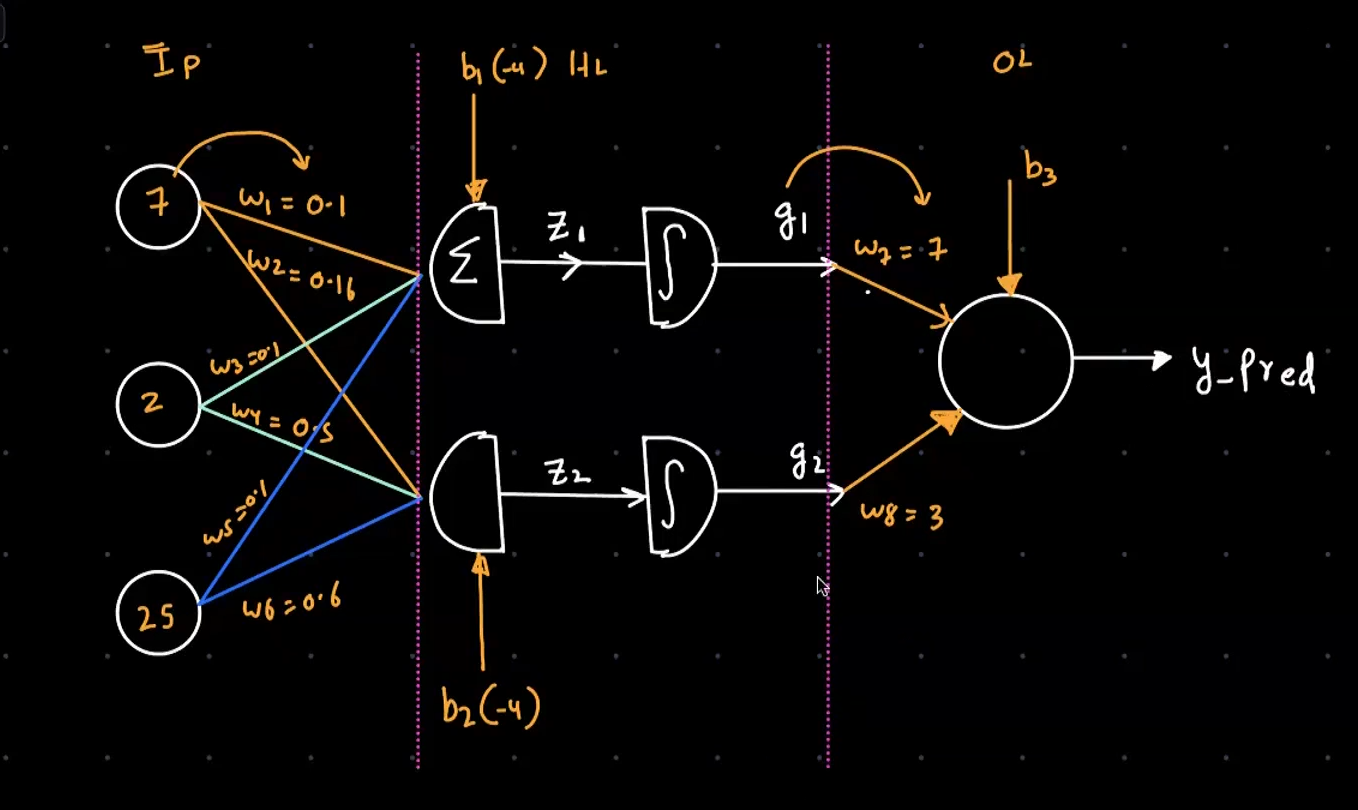


* Error 
    * Error = $Y_act - Y_pred$
    * we wants to update weight and biases until the error between (y actual) and (y predicted) is as minimum as possible
    * In order to minimise the error we need to implement diffent algorithms like-
        1. Gradient Descent
            * The most minimum point in any curve is known as global minima


* **Back Propogation**
    * The error from the output layer is propagated backward through the network.
    * The algorithm computes gradients (partial derivatives) of the loss with respect to each weight.
    * Using these gradients, weights are updated (usually using Gradient Descent) to minimize the loss.
    * 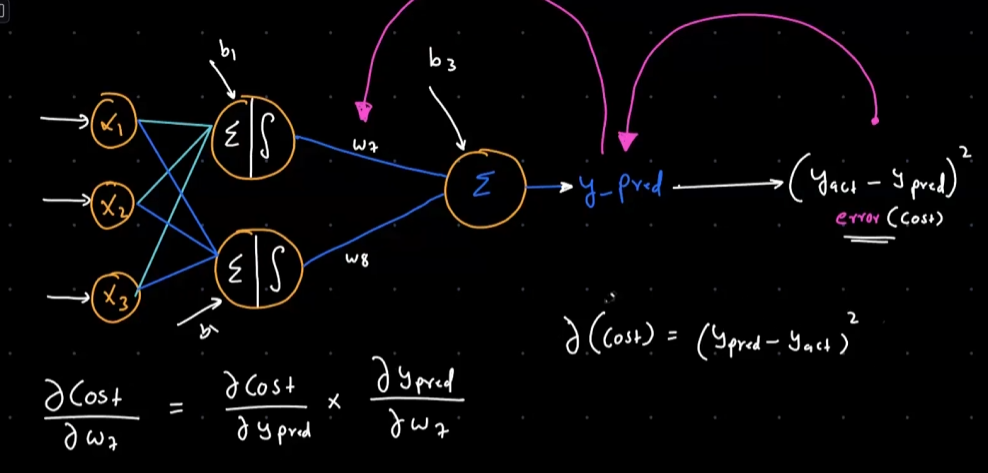
    * ![WhatsApp Image 2025-11-10 at 09.27.33_fa318213.jpg](<attachment:WhatsApp Image 2025-11-10 at 09.27.33_fa318213.jpg>)



now 5th video
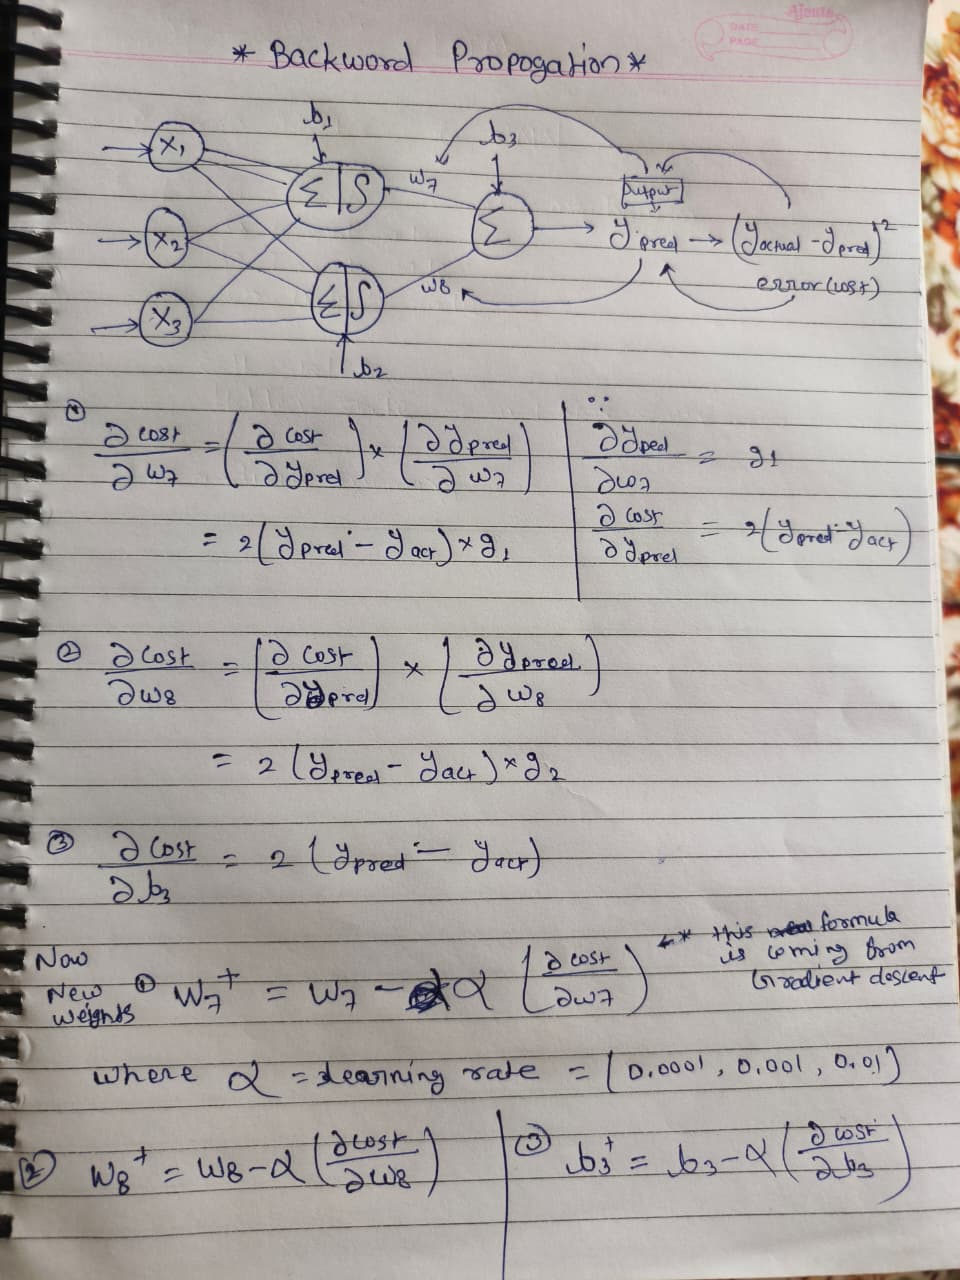

---
# Source Code

* **He Initialization** : 
    * When you randomly initialize the weight and bias values then your nural network will take time to get the answer right. 
    * SO instead of rondom initialization, in practicle world libraries random initialization karti hain but using some algorithms to make random values more accurate. and this initialization is called ***He Initialization***.
    

### Building Nural Network withought using any Library

In [9]:
import numpy as np
X = np.array([7,2,25]) #input features
actual = 85

#weights ans biases - are chosen randomly
W1,W2 = 0.1, 0.16,
W3,W4 = 0.1, 0.5
W5,W6 = 0.1, 0.6
W7,W8 = 7, 3
b1, b2, b3 = -4, -4, 12


#Activation function
def sigmoid(x):
  return 1 / (1 + np.exp(-x))


# Forword Propogation
def forward_propogation(X):
    Z1 = (W1 * X[0]) + (W3 * X[1]) + (W5 * X[2]) + b1
    Z2 = (W2 * X[0]) + (W4 * X[1]) + (W6 * X[2]) + b2
    G1 = sigmoid(Z1)
    G2 = sigmoid(Z2)
    y_pred = (W7 * G1) + (W8 * G2) + b3
    return Z1, Z2, G1, G2, y_pred

# Execute forward propogation
Z1, Z2, G1, G2, y_pred = forward_propogation(X)
print(f"Z1: {Z1:.2f}")
print(f"Z2: {Z2:.2f}")
print(f"G1: {G1:.2f}")
print(f"G2: {G2:.2f}")
print(f"y_pred : {y_pred:.2f}")

error = (actual - y_pred)
print(f"error : {error:.2f}")

Z1: -0.60
Z2: 13.12
G1: 0.35
G2: 1.00
y_pred : 17.48
error : 67.52


In [10]:
def sigmoid_derivative(x):
    return x * (1-x)

def backward_propogration(X,y, Z1, Z2, G1, G2, y_pred):
    # dCost = Dell Cost / Dell y+pred
    # dC = Dell Cost and dy_pred = Dell y_pred
    dC_dy_pred = 2 * (y_pred - y) #here y represnts actual data
    dC_dW7 = dC_dy_pred * G1
    dC_dW8 = dC_dy_pred * G2
    dC_db3 = dC_dy_pred

    dC_dG1 = dC_dy_pred * W7
    dC_dG2 = dC_dy_pred * W8

    dC_dZ1 = dC_dG1 * sigmoid_derivative(G1)
    dC_dZ2 = dC_dG2 * sigmoid_derivative(G2)

    #Weights
    dC_dW1 = dC_dZ1 * X[0]
    dC_dW2 = dC_dZ2 * X[0]
    dC_dW3 = dC_dZ1 * X[1]
    dC_dW4 = dC_dZ2 * X[1]
    dC_dW5 = dC_dZ1 * X[2]
    dC_dW6 = dC_dZ2 * X[2]
    #bias
    dC_db1 = dC_dZ1
    dC_db2 = dC_dZ2

    return dC_dW1, dC_dW2, dC_dW3, dC_dW4, dC_dW5, dC_dW6, dC_dW7, dC_dW8, dC_db1, dC_db2, dC_db3


gradients = backward_propogration(X, actual, Z1, Z2, G1, G2, y_pred)

print("=="*20)
print("WEIGHTS")
print(f"dC/dW1 : {gradients[0]}")
print(f"dC/dW2 : {gradients[1]}")
print(f"dC/dW3 : {gradients[2]}")
print(f"dC/dW4 : {gradients[3]}")
print(f"dC/dW5 : {gradients[4]}")
print(f"dC/dW6 : {gradients[5]}")
print(f"dC/dW7 : {gradients[6]}")
print(f"dC/dW8 : {gradients[7]}")
print("=="*20)
print("BIASES")
print(f"dC/db1 : {gradients[8]}")
print(f"dC/db2 : {gradients[9]}")
print(f"dC/db3 : {gradients[10]}")
print("=="*20)

WEIGHTS
dC/dW1 : -1513.847202927096
dC/dW2 : -0.005685043712575546
dC/dW3 : -432.5277722648846
dC/dW4 : -0.0016242982035930133
dC/dW5 : -5406.597153311058
dC/dW6 : -0.020303727544912664
dC/dW7 : -47.85028904412003
dC/dW8 : -135.03892959862114
BIASES
dC/db1 : -216.2638861324423
dC/db2 : -0.0008121491017965066
dC/db3 : -135.0392003155311


In [11]:
#UPDATE THE WEIGHTS AND BIASES - GRADIENT DESCENT
alpha = 0.01 #learning rate
W1 = W1 - alpha * gradients[0]
W2 = W2 - alpha * gradients[1]
W3 = W3 - alpha * gradients[2]
W4 = W4 - alpha * gradients[3]
W5 = W5 - alpha * gradients[4]
W6 = W6 - alpha * gradients[5]
W7 = W7 - alpha * gradients[6]
W8 = W8 - alpha * gradients[7]
print("=="*20)
print(f"UPDATED WEIGHT VALUES")
print("=="*20)
print(f"Updated W1 : {W1}")
print(f"Updated W2 : {W2}")
print(f"Updated W3 : {W3}")
print(f"Updated W4 : {W4}")
print(f"Updated W5 : {W5}")
print(f"Updated W6 : {W6}")
print(f"Updated W7 : {W7}")
print(f"Updated W8 : {W8}")


b1 = b1 - alpha * gradients[8]
b2 = b2 - alpha * gradients[9]
b3 = b3 - alpha * gradients[10]
print("=="*20)
print(f"UPDATED BIAS VALUES")
print("=="*20)
print(f"Updated b1 : {b1}")
print(f"Updated b2 : {b2}")
print(f"Updated b3 : {b3}")

UPDATED WEIGHT VALUES
Updated W1 : 15.23847202927096
Updated W2 : 0.16005685043712575
Updated W3 : 4.425277722648846
Updated W4 : 0.500016242982036
Updated W5 : 54.16597153311058
Updated W6 : 0.6002030372754491
Updated W7 : 7.4785028904412005
Updated W8 : 4.350389295986211
UPDATED BIAS VALUES
Updated b1 : -1.8373611386755768
Updated b2 : -3.999991878508982
Updated b3 : 13.350392003155312


### Building Nural Network using Library (Tenserflow)

In [12]:
import pandas as pd
import numpy as np

# Seed value is used to get same random numbers in each run in any environments
np.random.seed(10) # (0-inf) -ve number canniot be passed

# Data format :
# hours_of sleep | cups of coffee | travel time ----> productivity score

num_samples = 1000
X = np.random.rand(num_samples,3) * np.array([24, 10, 60])
Y = np.random.rand(num_samples) * 100


df = pd.DataFrame(X, columns=['hours_of_sleep','cups_of_coffee','travel_time'])
df.head(4)

,hours_of_sleep,cups_of_coffee,travel_time
0,18.511695,0.207519,38.018894
1,17.971293,4.985070,13.487799
2,4.753509,7.605307,10.146650
3,2.120156,6.853598,57.203601


In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


def create_custom_model():
    # input layer
    inputs = keras.Input(shape=(3,))

    # Dense method is used to connect the every single nuron of the input layer to every single nuron of the hidden layer
    # hidden layer - fully connected layer
    x = layers.Dense(2, activation='sigmoid')(inputs)

    # output layer
    outputs = layers.Dense(1, activation='linear')(x)

    # combine everything as one
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model


#call the function
my_first_neural_network = create_custom_model()


In [14]:
my_first_neural_network.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (44.00 B)

 Trainable params: 11 (44.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#every single neural network - >compile
my_first_neural_network.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss='mean_squared_error')
history = my_first_neural_network.fit(X, Y, epochs=150, batch_size=32, validation_split = 0.20) #not test

Epoch 1/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3342.5510 - val_loss: 3124.0212
Epoch 2/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3283.6553 - val_loss: 3047.6128
Epoch 3/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3174.6519 - val_loss: 2933.7273
Epoch 4/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3091.0186 - val_loss: 2870.5735
Epoch 5/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3033.8491 - val_loss: 2816.2859
Epoch 6/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2981.3955 - val_loss: 2765.7910
Epoch 7/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2931.8467 - val_loss: 2717.3462
Epoch 8/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2884.1841 - val_loss: 2670.3503
Epoch 9/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2837.5710 - val_loss: 2623.6162
Epoch 10/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2788.9126 - val_loss: 2570.6199
Epoch 11/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2726.3384 - val_loss: 2500.41

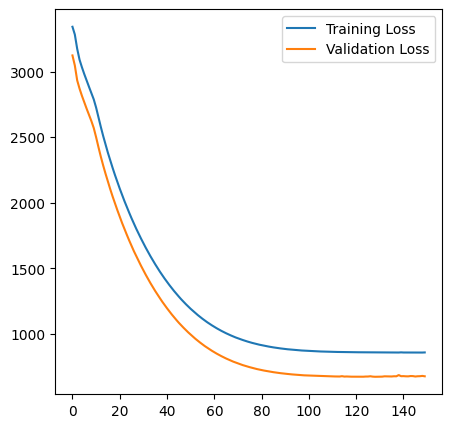

In [16]:
#good bad
plt.figure(figsize=(5,5))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.legend()

* **Corelation** : ?
    * Corelation only works on numerical data, never works on string data.
    * Corelation is not very useful.

* **VIF(Various Inflation Factor)**
* Scaler

* **Recursive Feature Elimination** : 
    * RFE is a feature selection technique used to automatically find the most important features for a machine learning model.
    * Before performing RFE we need to remove NaN values from the data.

* .pkl file